In [5]:
!git clone https://github.com/jordan-bird/CIFAKE-Real-and-AI-Generated-Synthetic-Images.git

fatal: destination path 'CIFAKE-Real-and-AI-Generated-Synthetic-Images' already exists and is not an empty directory.


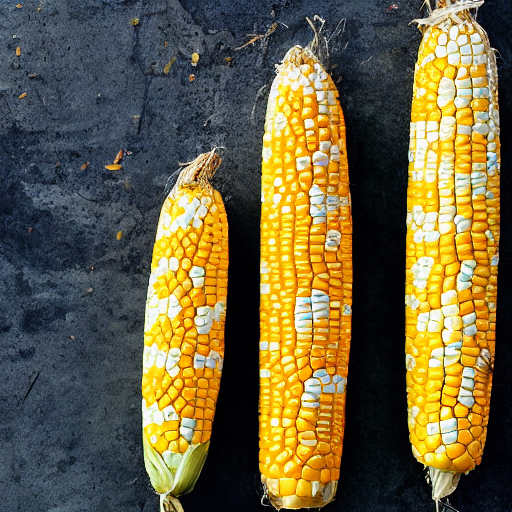

512
512


In [6]:

from IPython.display import Image as displayimage
from IPython.display import display
from PIL import Image 

display(displayimage(filename='./Data/Stable_diffusion_ready/train/ai/987_sdv5_00198.png', width=400))
display(displayimage(filename='./Data/Stable_diffusion_ready/train/nature/n03467068_19944.JPEG', width=400))

img = Image.open("./Data/Stable_diffusion_ready/train/ai/987_sdv5_00198.png")
width, height = img.size
print(width)
print(height)


In [7]:
# Count corrupted images in a given directory (recursively)
import os, pathlib
from PIL import Image, UnidentifiedImageError


def count_bad_images(folder: str, exts=None):
    """Traverse ``folder`` recursively and return how many files are unreadable by PIL.

    ``exts`` can be a tuple of file extensions to restrict the search (e.g. ('.jpg', '.png')).
    If ``exts`` is None all files are attempted.
    """
    folder = pathlib.Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"folder does not exist: {folder}")

    bad = 0
    total = 0

    for path in folder.rglob("*"):
        if path.is_file():
            if exts and path.suffix.lower() not in exts:
                continue
            total += 1
            try:
                with Image.open(path) as im:
                    im.verify()
            except (UnidentifiedImageError, Exception):
                bad += 1
        if total % 10000 == 0:
            print(f"{total} files checked")
    return total, bad


# example usage – adjust ``check_dir`` to whatever you want to inspect
check_dir = "/mnt/scratch/Stable_diffusion/Stable_diffusion_ready/train/nature"
total_files, corrupted = count_bad_images(check_dir, exts=(".jpeg", ".jpg", ".png"))
print(f"scanned {total_files} images; {corrupted} appear to be corrupted")


10000 files checked
20000 files checked
30000 files checked
40000 files checked
50000 files checked
60000 files checked
70000 files checked
80000 files checked
90000 files checked
100000 files checked
110000 files checked
120000 files checked
130000 files checked
140000 files checked
150000 files checked
scanned 153274 images; 3648 appear to be corrupted


In [8]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.io import read_image
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from PIL import Image
import torch.nn.functional as F
from datetime import datetime
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# ---------------------------------------------------------
# 1) CONFIGURATION
# ---------------------------------------------------------
DATA_DIR = "/mnt/scratch/Stable_diffusion/Stable_diffusion_ready"
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.backends.cudnn.benchmark = True

# Model hyperparameters (from paper search space)
CONV_FILTERS = 32          # {16, 32, 64, 128}
CONV_LAYERS = 2            # {1, 2, 3}
DENSE_NEURONS = 64         # {32, 64, 128, 256, 512, 1024, 2048, 4096}
DENSE_LAYERS = 1           # {1, 2, 3}

# Grad-CAM / output config
OUT_DIR = "/home/cv04f26/ComputerVisionProject/gradcam_outputs"
NUM_CAM_SAMPLES = 12
IMAGE_SIZE = 256


# ---------------------------------------------------------
# 2) DATA PIPELINE (torchvision.io + tensor-native transforms)
# ---------------------------------------------------------
# Prefer torchvision v2 transforms; fallback to functional if v2 missing.
_use_v2 = False
tensor_transform = None

try:
    import torchvision.transforms.v2 as T
    from torchvision.transforms import InterpolationMode
    _use_v2 = True
    tensor_transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR, antialias=True),
        T.ToDtype(torch.float32, scale=True),  # scales uint8 -> float32 [0,1]
    ])
except Exception:
    from torchvision.transforms import InterpolationMode
    from torchvision.transforms import functional as TF

    def tensor_transform(img: torch.Tensor) -> torch.Tensor:
        # img: Tensor uint8 [C,H,W]
        img = TF.resize(img, [IMAGE_SIZE, IMAGE_SIZE],
                        interpolation=InterpolationMode.BILINEAR, antialias=True)
        img = img.float() / 255.0
        return img

class SafeImageFolder(datasets.ImageFolder):
    """
    Faster loader using torchvision.io.read_image (no PIL for reading).
    - Ensures 3 channels (expand grayscale, drop alpha)
    - Applies tensor-native transforms
    - Skips corrupted/unreadable images (returns None)
    """
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            img = read_image(path)  # uint8 tensor [C,H,W]
            if img.ndim != 3:
                return None
            # Normalize channels to 3 (RGB-like)
            if img.shape[0] == 1:
                img = img.expand(3, -1, -1)      # grayscale -> 3-ch
            elif img.shape[0] > 3:
                img = img[:3, ...]               # drop alpha/extras

            if self.transform is not None:
                img = self.transform(img)
            else:
                img = img.float() / 255.0

            return img, target
        except (RuntimeError, OSError, ValueError):
            # read_image raises RuntimeError for decode errors
            return None  # mark as bad

# Collate function to remove None samples
def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    imgs, labels = zip(*batch)
    return torch.utils.data.dataloader.default_collate(list(zip(imgs, labels)))

train_data = SafeImageFolder(os.path.join(DATA_DIR, "train"), transform=tensor_transform)
test_data  = SafeImageFolder(os.path.join(DATA_DIR, "val"),   transform=tensor_transform)
print(DEVICE)
pin_mem = (DEVICE == "cuda")

train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=16, persistent_workers=True, prefetch_factor=8,
    pin_memory=pin_mem, collate_fn=collate_skip_none
)
test_loader  = DataLoader(
    test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_skip_none
)

idx_to_class = {v: k for k, v in train_data.class_to_idx.items()}   # e.g., 0: AI, 1: REAL

# ---------------------------------------------------------
# 3) MODEL DEFINITION (returns logits; no Sigmoid in forward)
# ---------------------------------------------------------
class CIFAKE_CNN(nn.Module):
    def __init__(self, conv_filters, conv_layers, dense_neurons, dense_layers):
        super().__init__()

        conv_blocks = []
        in_channels = 3

        for _ in range(conv_layers):
            conv_blocks.append(nn.Conv2d(in_channels, conv_filters, kernel_size=3, stride=1, padding=1))
            conv_blocks.append(nn.ReLU())
            conv_blocks.append(nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = conv_filters

        self.conv = nn.Sequential(*conv_blocks)
        reduction = 2 ** conv_layers
        flattened_size = (IMAGE_SIZE // reduction) * (IMAGE_SIZE // reduction) * conv_filters

        dense_blocks = []
        in_features = flattened_size

        for _ in range(dense_layers):
            dense_blocks.append(nn.Linear(in_features, dense_neurons))
            dense_blocks.append(nn.ReLU())
            in_features = dense_neurons

        dense_blocks.append(nn.Linear(in_features, 1))   # binary logit
        self.fc_logits = nn.Sequential(*dense_blocks)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        logit = self.fc_logits(x)
        return logit  # (B,1) logits

model = CIFAKE_CNN(CONV_FILTERS, CONV_LAYERS, DENSE_NEURONS, DENSE_LAYERS).to(DEVICE)

# Use logits-safe, autocast-safe BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler(enabled=(DEVICE == "cuda"))

# ---------------------------------------------------------
# 4) TRAINING / EVAL
# ---------------------------------------------------------
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    steps = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for batch in loop:
        if batch is None:
            continue
        images, labels = batch
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        steps += 1
        loop.set_postfix(loss=(running_loss / max(steps, 1)))

    avg_loss = running_loss / max(steps, 1)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

def evaluate(model):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
            for batch in test_loader:
                if batch is None:
                    continue
                images, labels = batch
                images = images.to(DEVICE, non_blocking=True)
                logits = model(images)
                probs = torch.sigmoid(logits)

                predictions = (probs.float().cpu().numpy() > 0.5).astype(int)
                preds.extend(predictions.flatten())
                trues.extend(labels.numpy().flatten())

    if len(preds) == 0:
        print("\n--- TEST RESULTS ---")
        print("No valid samples to evaluate.")
        return 0, 0, 0, 0

    accuracy  = np.mean(np.array(preds) == np.array(trues))
    precision = precision_score(trues, preds, zero_division=0)
    recall    = recall_score(trues, preds, zero_division=0)
    f1        = f1_score(trues, preds, zero_division=0)

    print("\n--- TEST RESULTS ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    return accuracy, precision, recall, f1

# ---------------------------------------------------------
# 5) GRAD-CAM IMPLEMENTATION
# ---------------------------------------------------------
def find_last_conv_layer(module: nn.Module):
    last_conv = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last_conv = m
    if last_conv is None:
        raise RuntimeError("No Conv2d layer found for Grad-CAM.")
    return last_conv

class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def forward_hook(module, inputs, output):
            self.activations = output.detach()

        def full_backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.fwd_handle = self.target_layer.register_forward_hook(forward_hook)

        self.bwd_handle = self.target_layer.register_full_backward_hook(full_backward_hook)

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    @torch.no_grad()
    def _normalize_cam(self, cam):
        B, H, W = cam.shape
        cam = cam.view(B, -1)
        cam_min = cam.min(dim=1, keepdim=True).values
        cam_max = cam.max(dim=1, keepdim=True).values
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-6)
        return cam.view(B, H, W)

    def generate(self, input_tensor: torch.Tensor, use_logits: bool = True):
        self.model.zero_grad()
        output = self.model(input_tensor)                    # (B,1) logits
        target = output.squeeze(1)
        target.sum().backward()
        grads = self.gradients            # (B, C, H, W)
        activs = self.activations         # (B, C, H, W)
        weights = grads.mean(dim=(2, 3), keepdim=True)  # (B, C, 1, 1)
        cam = (weights * activs).sum(dim=1)            # (B, H, W)
        cam = torch.relu(cam)
        cam = self._normalize_cam(cam)
        cam = cam.unsqueeze(1)
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False).squeeze(1)
        return cam  # (B,IMAGE_SIZE,IMAGE_SIZE) in [0,1]

# ---------------------------------------------------------
# 6) VISUALIZATION UTILITIES (PIL only for saving)
# ---------------------------------------------------------
def to_uint8_img(t: torch.Tensor):
    t = t.detach().cpu().clamp(0, 1)
    arr = (t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return arr

def colorize_cam(cam_2d: np.ndarray, cmap_name="jet"):
    colormap = cm.get_cmap(cmap_name)
    heatmap = colormap(cam_2d)[:, :, :3]
    return heatmap.astype(np.float32)

def overlay_heatmap_on_image(img_uint8: np.ndarray, heatmap_rgb: np.ndarray, alpha=0.5):
    img_float = img_uint8.astype(np.float32) / 255.0
    overlay = heatmap_rgb * alpha + img_float * (1 - alpha)
    overlay = (np.clip(overlay, 0, 1) * 255).astype(np.uint8)
    return overlay

def save_triplet(input_img, heatmap_img, overlay_img, prefix, out_dir, upscale=IMAGE_SIZE):
    os.makedirs(out_dir, exist_ok=True)
    inp = Image.fromarray(input_img).resize((upscale, upscale), Image.NEAREST)
    htm = Image.fromarray((heatmap_img * 255).astype(np.uint8)).resize((upscale, upscale), Image.NEAREST)
    ovl = Image.fromarray(overlay_img).resize((upscale, upscale), Image.NEAREST)
    inp.save(os.path.join(out_dir, f"{prefix}_input.png"))
    htm.save(os.path.join(out_dir, f"{prefix}_heatmap.png"))
    ovl.save(os.path.join(out_dir, f"{prefix}_overlay.png"))

def generate_gradcam_samples(n_samples=NUM_CAM_SAMPLES):
    model.eval()
    last_conv = find_last_conv_layer(model)
    cam = GradCAM(model, last_conv)

    saved = 0
    stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    base_out = os.path.join(OUT_DIR, stamp)
    os.makedirs(base_out, exist_ok=True)

    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if saved >= n_samples:
                break
            if batch is None:
                continue

            images, labels = batch
            images = images.to(DEVICE, non_blocking=True)

            with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
                logits = model(images)
                probs = torch.sigmoid(logits)

            preds = (probs > 0.5).long().squeeze(1).cpu()

            for i in range(images.size(0)):
                if saved >= n_samples:
                    break

                label = int(labels[i].item())
                pred  = int(preds[i].item())

                with torch.enable_grad():
                    img = images[i].unsqueeze(0).detach().to(DEVICE)
                    img.requires_grad_(True)
                    #with autocast(device_type=DEVICE, dtype=torch.float16, enabled=(DEVICE == "cuda")):
                    cam_map = cam.generate(img, use_logits=True)[0].cpu().numpy()

                input_u8   = to_uint8_img(images[i])
                heat_rgb   = colorize_cam(cam_map, cmap_name="jet")
                overlay_u8 = overlay_heatmap_on_image(input_u8, heat_rgb, alpha=0.55)

                prefix = f"idx{batch_idx:03d}_{i:02d}_true-{idx_to_class[label]}_pred-{idx_to_class[pred]}"
                save_triplet(input_u8, heat_rgb, overlay_u8, prefix, base_out, upscale=IMAGE_SIZE)

                saved += 1

    cam.remove_hooks()
    print(f"\n[Grad-CAM] Saved {saved} visualizations to: {base_out}")
print(DEVICE)


cuda
cuda


In [10]:
# CONV_FILTER {16, 32, 64, 128}
# CONV_LAYER{1, 2, 3}
# DENSE_NEURON {32, 64, 128, 256, 512, 1024, 2048, 4096}
# DENSE_LAYERS [1,3]
CONV_FILTER = 32
CONV_LAYER = 2
DENSE_NEURON = 64
DENSE_LAYER = 1

for i in range(5):

    if i==1:
        CONV_FILTER = 32
        CONV_LAYER = 3
        DENSE_NEURON = 64
        DENSE_LAYER = 3
    elif i==2:  
        CONV_FILTER = 32
        CONV_LAYER = 3
        DENSE_NEURON = 4096
        DENSE_LAYER = 1
    elif i==3:
        CONV_FILTER = 32
        CONV_LAYER = 3
        DENSE_NEURON = 4096
        DENSE_LAYER = 3
    elif i==4:
        CONV_FILTER = 64
        CONV_LAYER = 2
        DENSE_NEURON = 64
        DENSE_LAYER = 1

    model = CIFAKE_CNN(CONV_FILTER, CONV_LAYER, DENSE_NEURON, DENSE_LAYER).to(DEVICE)
    model.load_state_dict(torch.load(f"/home/cv04f26/ComputerVisionProject/models/model_{CONV_FILTER}_{CONV_LAYER}_{DENSE_NEURON}_{DENSE_LAYER}.pth"))
    print(f"model{i}")
    evaluate(model)

model = CIFAKE_CNN(CONV_FILTER, CONV_LAYER, DENSE_NEURON, DENSE_LAYER).to(DEVICE)



model0

--- TEST RESULTS ---
Accuracy : 0.9354
Precision: 0.9410
Recall   : 0.9290
F1 Score : 0.9350
model1

--- TEST RESULTS ---
Accuracy : 0.9471
Precision: 0.9394
Recall   : 0.9557
F1 Score : 0.9475
model2

--- TEST RESULTS ---
Accuracy : 0.9359
Precision: 0.9384
Recall   : 0.9331
F1 Score : 0.9358
model3

--- TEST RESULTS ---
Accuracy : 0.9371
Precision: 0.9358
Recall   : 0.9385
F1 Score : 0.9372
model4

--- TEST RESULTS ---
Accuracy : 0.9416
Precision: 0.9384
Recall   : 0.9451
F1 Score : 0.9418


In [ ]:

# ---------------------------------------------------------
# 7) MAIN
# ---------------------------------------------------------
if __name__ == "__main__":
    print(model)
    for epoch in range(EPOCHS):
        train_one_epoch(epoch)
    evaluate()
    generate_gradcam_samples(NUM_CAM_SAMPLES)

NameError: name 'model' is not defined

: 

In [ ]:

import os, glob
from PIL import Image
import matplotlib.pyplot as plt

folder = sorted(glob.glob("/mnt/scratch/Stable_diffussion/gradcam_outputs/*"))[-1]  # latest run
triplets = sorted(glob.glob(os.path.join(folder, "*_overlay.png")))

def show_triplet(overlay_path):
    prefix = overlay_path.replace("_overlay.png", "")
    inp = Image.open(prefix + "_input.png")
    htm = Image.open(prefix + "_heatmap.png")
    ovl = Image.open(overlay_path)

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1); plt.imshow(inp); plt.axis("off"); plt.title("Input")
    plt.subplot(1, 3, 2); plt.imshow(htm); plt.axis("off"); plt.title("Heatmap")
    plt.subplot(1, 3, 3); plt.imshow(ovl); plt.axis("off"); plt.title("Overlay")
    plt.tight_layout(); plt.show()

show_triplet(triplets[0])  # visualize the first saved example


IndexError: list index out of range

: 

In [ ]:
import math

N = 8  # how many examples to show
paths = sorted(glob.glob(os.path.join(folder, "*_overlay.png")))[:N]
cols = 4
rows = math.ceil(N / cols)

plt.figure(figsize=(4*cols, 4*rows))
for i, p in enumerate(paths):
    plt.subplot(rows, cols, i+1)
    plt.imshow(Image.open(p))
    plt.axis("off")
    plt.title(os.path.basename(p), fontsize=10)
plt.tight_layout(); plt.show()


NameError: name 'folder' is not defined

: 

: 